In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import torch


Saved 32-channel brainstem probe definition to /media/ubuntu/sda/mouse_test/probe/brainstem_32ch.json


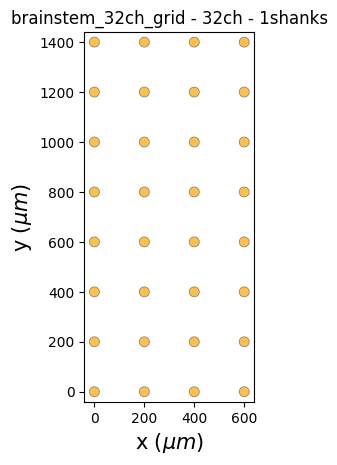

In [2]:
# Create a 32-channel (4 x 8) probe layout with 200 µm spacing
from probeinterface import Probe
from probeinterface.plotting import plot_probe

# Define grid dimensions and spacing (µm)
num_cols = 4
num_rows = 8
spacing = 200.0  # µm

# Generate positions for a 4 (x-axis) by 8 (y-axis) grid
positions = []
for row in range(num_rows):
    for col in range(num_cols):
        x = col * spacing
        y = row * spacing
        positions.append([x, y])

# Create the probe and set contacts
brainstem_probe = Probe(ndim=2)
brainstem_probe.set_contacts(
    positions=positions,
    shapes='circle',
    contact_ids=list(range(32)),
    shape_params={'radius': 20.0}
)

# Set device channel indices to match contact indices
brainstem_probe.set_device_channel_indices(list(range(32)))

# Annotate for clarity
brainstem_probe.annotate(name='brainstem_32ch_grid', description='4x8 grid, 200 µm spacing')

# Visualize and save the probe definition
plot_probe(brainstem_probe)
write_probeinterface('/media/ubuntu/sda/mouse_test/probe/brainstem_32ch.json', brainstem_probe)
print('Saved 32-channel brainstem probe definition to /media/ubuntu/sda/mouse_test/probe/brainstem_32ch.json')


In [3]:
file_list = os.listdir(f"/media/ubuntu/sda/mouse_test/raw_data/20251121_RBD_EEG_251121_222522")
file_list.remove("settings.xml")
file_list.remove("20251121_RBD_EEG_251122_072721.rhs")
file_list.remove("20251121_RBD_EEG_251122_070922.rhs")
file_list.remove("20251121_RBD_EEG_251122_071022.rhs")
file_list.remove("20251121_RBD_EEG_251122_071121.rhs")
file_list.remove("20251121_RBD_EEG_251122_071222.rhs")
file_list.remove("20251121_RBD_EEG_251122_071321.rhs")
file_list.remove("20251121_RBD_EEG_251122_071421.rhs")
file_list.remove("20251121_RBD_EEG_251122_071521.rhs")
file_list.remove("20251121_RBD_EEG_251122_071621.rhs")
file_list.remove("20251121_RBD_EEG_251122_071721.rhs")
file_list.remove("20251121_RBD_EEG_251122_071821.rhs")
file_list.remove("20251121_RBD_EEG_251122_071921.rhs")
file_list.remove("20251121_RBD_EEG_251122_072021.rhs")
file_list.remove("20251121_RBD_EEG_251122_072121.rhs")
file_list.remove("20251121_RBD_EEG_251122_072221.rhs")
file_list.remove("20251121_RBD_EEG_251122_072321.rhs")
file_list.remove("20251121_RBD_EEG_251122_072421.rhs")
file_list.remove("20251121_RBD_EEG_251122_072521.rhs")
file_list.remove("20251121_RBD_EEG_251122_072621.rhs")


file_list = sorted(file_list)
recording_raw_list = []
trigger_list = []
for file in file_list:
    recording_raw_list.append(se.read_intan(f"/media/ubuntu/sda/mouse_test/raw_data/20251121_RBD_EEG_251121_222522/{file}", stream_id= '0'))
    trigger_list.append(se.read_intan(f"/media/ubuntu/sda/mouse_test/raw_data/20251121_RBD_EEG_251121_222522/{file}", stream_id= '3'))
recording_raw = concatenate_recordings(recording_list=recording_raw_list)
trigger = concatenate_recordings(recording_list=trigger_list)
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

In [4]:
trigger_index = 723956
starting_index = int(117.5777 * 20000)

# EEG索引（原始值）
RBD_index_EEG = [int(3394.122 * 20000), int(10170.286 * 20000), int(22192.19 * 20000), int(22213.552 * 20000), int(22235.938 * 20000)]
REM_start_index_EEG = [int(3347.822 * 20000), int(8948.246 * 20000), int(10138.905 * 20000), int(29171.351 * 20000)]
REM_end_index_EEG = [int(3407.211 * 20000), int(8977.733 * 20000), int(10175.745 * 20000), int(29191.595 * 20000)]

# 转换为recording的计时索引（trigger_index和starting_index对齐）
# 转换公式：recording_index = trigger_index + (EEG_index - starting_index)
RBD_index = [trigger_index + (idx - starting_index) for idx in RBD_index_EEG]
REM_start_index = [trigger_index + (idx - starting_index) for idx in REM_start_index_EEG]
REM_end_index = [trigger_index + (idx - starting_index) for idx in REM_end_index_EEG]

In [5]:
recording_slice_1 = recording_f.time_slice(start_time= 60000000 / 20000, end_time = 70000000 / 20000)
recording_slice_2 = recording_f.time_slice(start_time= 170000000 / 20000, end_time = 180000000 / 20000)
recording_slice_3 = recording_f.time_slice(start_time= 190000000 / 20000, end_time = 205000000 / 20000)
recording_slice_4 = recording_f.time_slice(start_time= 570000000 / 20000, end_time = 585000000 / 20000)

recording_concat = si.concatenate_recordings([recording_slice_1, recording_slice_2, recording_slice_3, recording_slice_4])

In [6]:
probe_30channel = read_probeinterface('/media/ubuntu/sda/mouse_test/probe/brainstem_32ch.json')
recording_concat = recording_concat.set_probegroup(probe_30channel)

In [11]:
output_folder = '/media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522'
recording_preprocessed = recording_concat.save(format="binary")
print(recording_preprocessed)

sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "spike_amplitudes",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

Use cache_folder=/tmp/spikeinterface_cache/tmpnx6pmu1c/2LOCVCNT
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=20,000 - chunk_memory=1.22 MiB - total_memory=1.22 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2500 [00:00<?, ?it/s]

BinaryFolderRecording: 32 channels - 20.0kHz - 1 segments - 50,000,000 samples 
                       2,500.00s (41.67 minutes) - int16 dtype - 2.98 GiB


100%|██████████| 4/4 [02:59<00:00, 44.79s/it]


estimate_sparsity (no parallelization):   0%|          | 0/2500 [00:00<?, ?it/s]

...

write_binary_recording (no parallelization):   0%|          | 0/2500 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/52 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/52 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/2500 [00:00<?, ?it/s]

Run:
phy template-gui  /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/phy_folder_for_kilosort/params.py


In [12]:
def load_cluster_info(phy_dir: str) -> pd.DataFrame:
    """读取 phy_folder_for_kilosort/cluster_info.tsv 为 DataFrame。
    该表包含所有需要的 cluster 级指标。
    如果cluster_info.tsv不存在，则尝试从其他文件构建基本信息。
    同时计算并添加mean_waveform信息。
    """
    path = os.path.join(phy_dir, CLUSTER_INFO_FILENAME)
    
    if os.path.exists(path):
        df = pd.read_csv(path, sep='\t')
        # 标准化主键列名
        if 'cluster_id' not in df.columns:
            raise ValueError(f"{path} 中缺少 cluster_id 列")
    else:
        print(f"警告: {path} 不存在，尝试从其他文件构建cluster信息")
        
        # 尝试从cluster_group.tsv构建基本信息
        cluster_group_path = os.path.join(phy_dir, "cluster_group.tsv")
        if os.path.exists(cluster_group_path):
            df = pd.read_csv(cluster_group_path, sep='\t')
            if 'cluster_id' not in df.columns:
                raise ValueError(f"{cluster_group_path} 中缺少 cluster_id 列")
        else:
            # 如果都没有，从spike_clusters.npy中提取唯一的cluster_id
            spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
            if os.path.exists(spike_clusters_path):
                spike_clusters = np.load(spike_clusters_path)
                unique_clusters = np.unique(spike_clusters)
                df = pd.DataFrame({
                    'cluster_id': unique_clusters,
                    'group': 'unsorted'  # 默认分组
                })
            else:
                raise ValueError(f"无法找到任何cluster信息文件: {phy_dir}")
    
    # 计算mean_waveform并展开为多列添加到DataFrame
    mean_waveforms = compute_mean_waveform(phy_dir)
    if mean_waveforms:
        # 确定waveform的长度（通常是90个时间点）
        waveform_length = None
        for waveform in mean_waveforms.values():
            if waveform is not None:
                waveform_length = len(waveform)
                break
        
        if waveform_length is not None:
            # 创建waveform列名
            waveform_columns = [f'mean_waveform_{i}' for i in range(waveform_length)]
            
            # 为每个cluster创建waveform数据
            waveform_data = {}
            for cluster_id in df['cluster_id']:
                if cluster_id in mean_waveforms and mean_waveforms[cluster_id] is not None:
                    waveform = mean_waveforms[cluster_id]
                    # 确保waveform长度一致
                    if len(waveform) == waveform_length:
                        waveform_data[cluster_id] = waveform
                    else:
                        # 如果长度不匹配，用NaN填充或截断
                        padded_waveform = np.full(waveform_length, np.nan)
                        padded_waveform[:min(len(waveform), waveform_length)] = waveform[:min(len(waveform), waveform_length)]
                        waveform_data[cluster_id] = padded_waveform
                else:
                    # 没有waveform数据的cluster用NaN填充
                    waveform_data[cluster_id] = np.full(waveform_length, np.nan)
            
            # 将waveform数据转换为DataFrame并合并
            waveform_df = pd.DataFrame.from_dict(waveform_data, orient='index', columns=waveform_columns)
            waveform_df.index.name = 'cluster_id'
            waveform_df = waveform_df.reset_index()
            
            # 合并到主DataFrame
            df = df.merge(waveform_df, on='cluster_id', how='left')
            print(f"成功添加mean_waveform信息到 {len(mean_waveforms)} 个clusters，展开为 {waveform_length} 列")
        else:
            print("警告: 无法确定waveform长度")
    else:
        print("警告: 无法计算mean_waveform信息")
    
    return df


def load_spike_level(phy_dir: str) -> pd.DataFrame:
    """读取 spike 层面的 numpy 文件并返回 DataFrame: [cluster, time]
    time 使用原始采样点，不做单位转换。
    """
    spike_clusters = np.load(os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME))
    spike_times = np.load(os.path.join(phy_dir, SPIKE_TIMES_FILENAME))
    # 展平为一维
    spike_clusters = np.asarray(spike_clusters).reshape(-1)
    spike_times = np.asarray(spike_times).reshape(-1)
    if spike_clusters.shape[0] != spike_times.shape[0]:
        raise ValueError(f"spike_clusters 与 spike_times 行数不一致: {phy_dir}")
    df = pd.DataFrame({
        'cluster_id': spike_clusters.astype(int),
        'time': spike_times.astype(int),
    })
    return df


def compute_mean_waveform(phy_dir: str) -> dict:
    """计算每个cluster的平均波形
    
    Returns:
        dict: {cluster_id: mean_waveform_array}
    """
    templates_path = os.path.join(phy_dir, "templates.npy")
    spike_templates_path = os.path.join(phy_dir, "spike_templates.npy")
    spike_clusters_path = os.path.join(phy_dir, SPIKE_CLUSTERS_FILENAME)
    
    if not all(os.path.exists(p) for p in [templates_path, spike_templates_path, spike_clusters_path]):
        print("警告: 缺少计算waveform所需的文件，跳过mean_waveform计算")
        return {}
    
    # 加载数据
    templates = np.load(templates_path)  # shape: (n_templates, n_timepoints, n_channels)
    spike_templates = np.load(spike_templates_path).flatten()  # shape: (n_spikes,)
    spike_clusters = np.load(spike_clusters_path).flatten()  # shape: (n_spikes,)
    
    # 创建cluster到template的映射
    cluster_template_map = {}
    for spike_idx, (cluster_id, template_id) in enumerate(zip(spike_clusters, spike_templates)):
        if cluster_id not in cluster_template_map:
            cluster_template_map[cluster_id] = template_id
    
    # 计算每个cluster的mean_waveform
    mean_waveforms = {}
    for cluster_id, template_id in cluster_template_map.items():
        if template_id < templates.shape[0]:
            # 获取该cluster对应的template
            template = templates[template_id]  # shape: (n_timepoints, n_channels)
            # 如果模板是2D的，取第一个通道或平均所有通道
            if template.ndim == 2:
                if template.shape[1] == 1:
                    # 只有一个通道
                    mean_waveform = template[:, 0]
                else:
                    # 多个通道，取平均
                    mean_waveform = np.mean(template, axis=1)
            else:
                # 1D情况
                mean_waveform = template
            mean_waveforms[cluster_id] = mean_waveform
    
    return mean_waveforms

In [13]:
CLUSTER_INFO_FILENAME = "cluster_info.tsv"

SPIKE_CLUSTERS_FILENAME = "spike_clusters.npy"
SPIKE_TIMES_FILENAME = "spike_times.npy"

In [19]:
ROOT_SORT_DIR = "/media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/phy_folder_for_kilosort"
cluster_inf = load_cluster_info(phy_dir=ROOT_SORT_DIR)
spike_inf = load_spike_level(phy_dir=ROOT_SORT_DIR)
cluster_inf = cluster_inf[(cluster_inf['group'] == 'good')]
spike_inf = spike_inf[spike_inf['cluster_id'].isin(cluster_inf['cluster_id'].values)]

成功添加mean_waveform信息到 51 个clusters，展开为 60 列


已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/waveform_grid.pdf


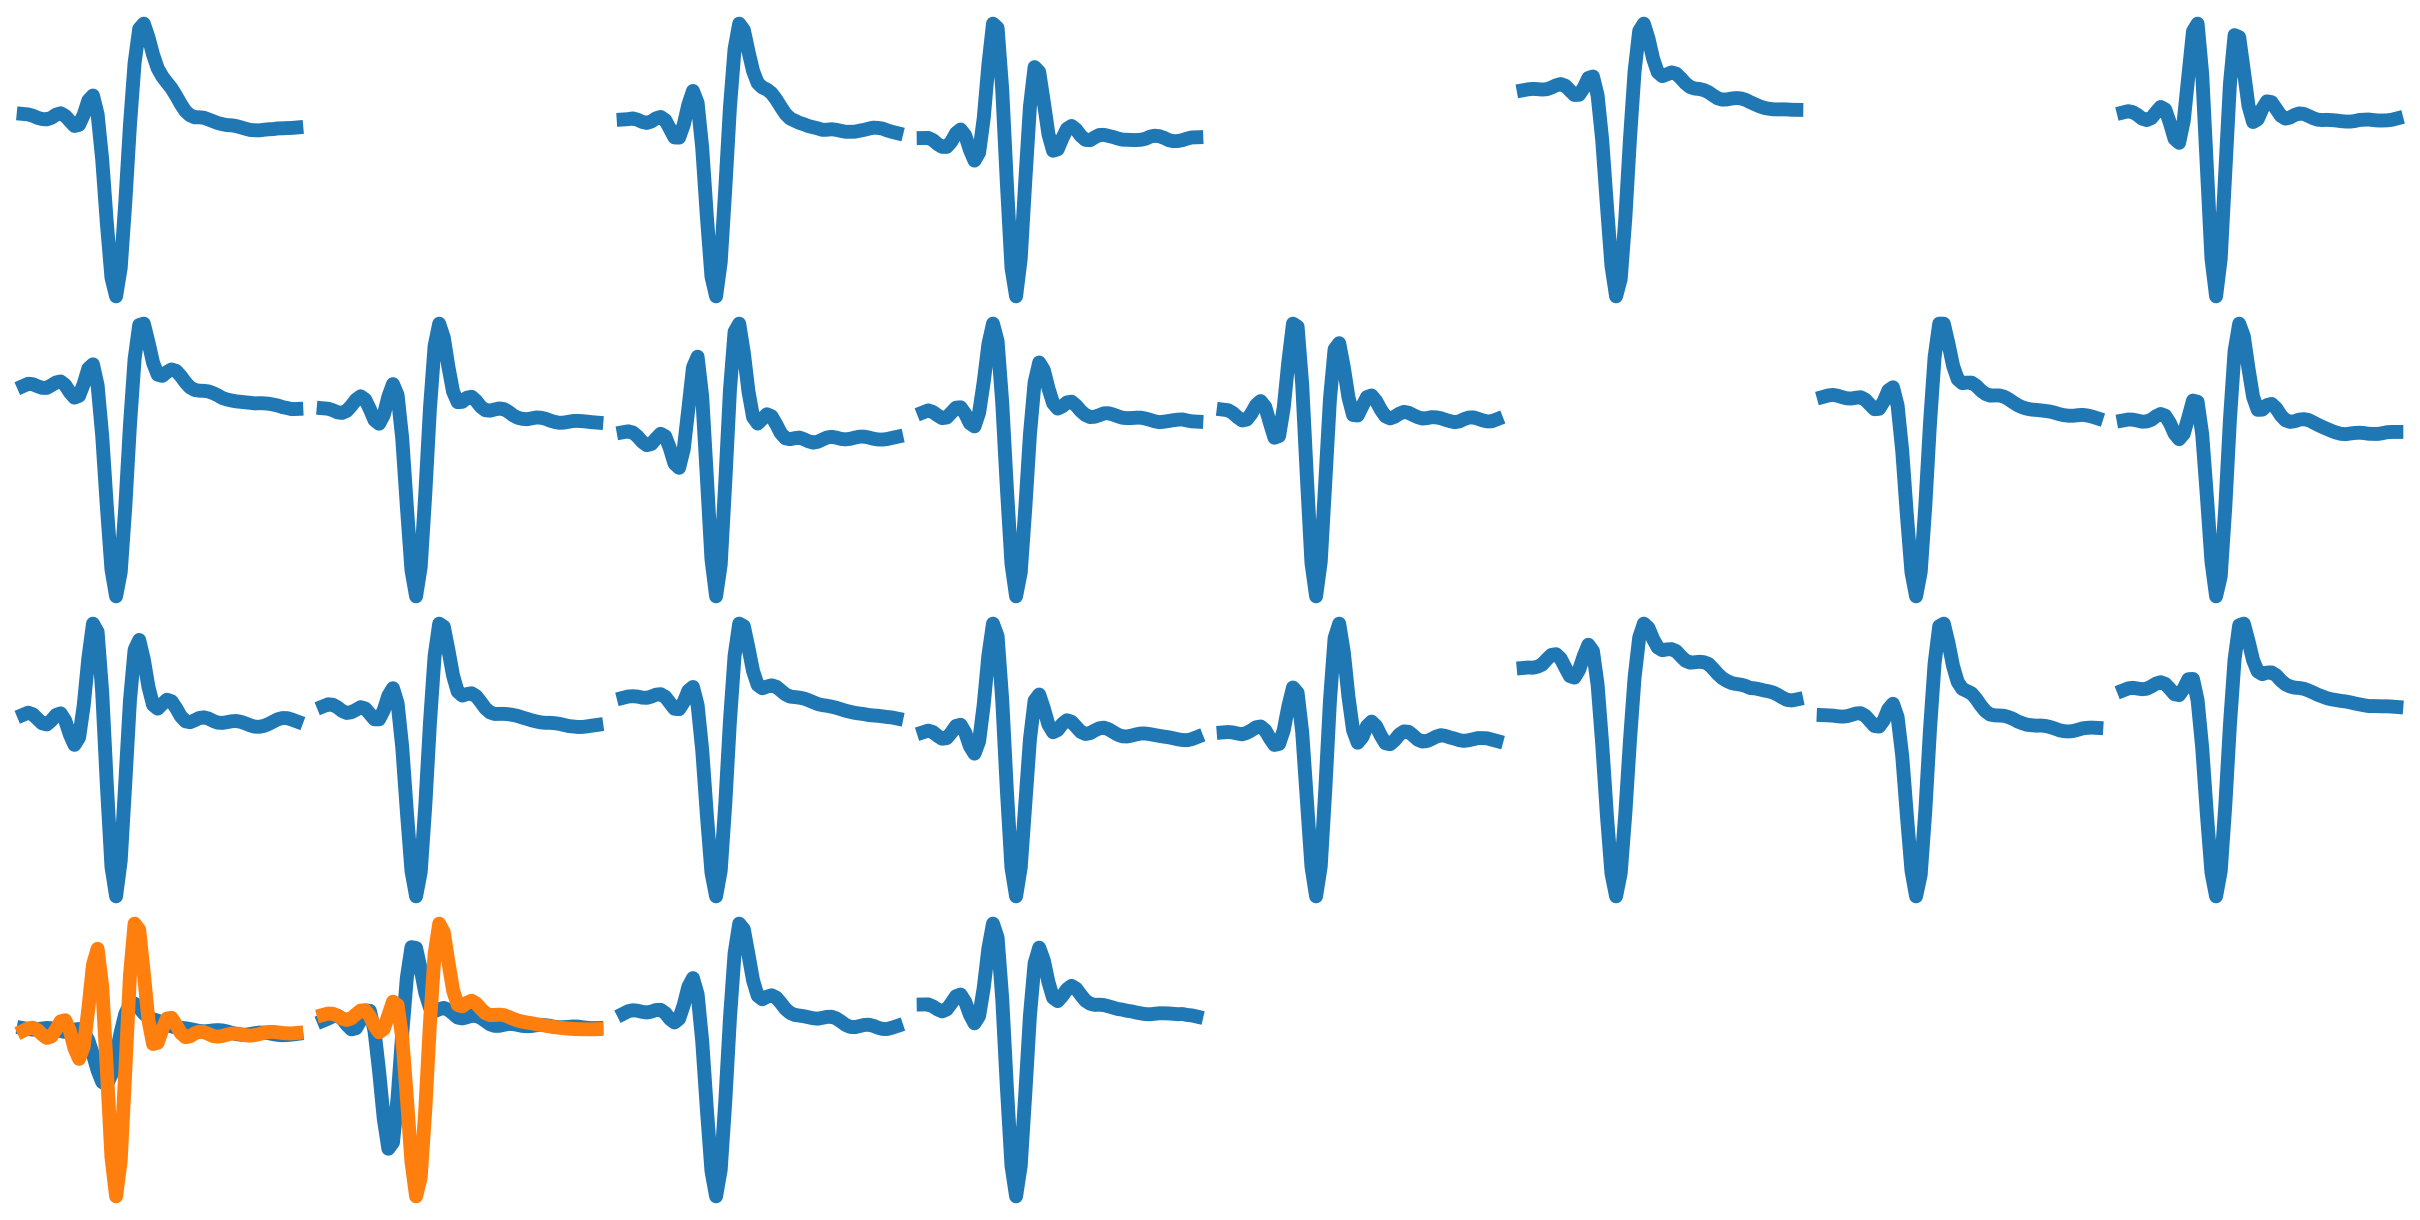

In [21]:
def plot_waveform_grid(cluster_inf_all, date, n_rows=4, n_cols=8, figsize=(24, 12), output_name=None):
    """
    绘制单个日期的waveform网格图，16×16布局，每个子图代表一个channel
    两天都能追踪到的cluster: #ED7B85（红色）
    只在当前这一天出现的cluster: #5E9FD1（蓝色）
    
    Parameters:
    -----------
    cluster_inf_all : DataFrame
        包含cluster信息和waveform数据，必须包含neuron列
    date : int
        要绘制的日期（1或2）
    n_rows : int
        行数，默认16
    n_cols : int
        列数，默认16
    figsize : tuple
        图形大小
    output_name : str
        输出PDF文件名，如果为None则不保存
    """
    
    # 筛选指定日期的数据
    
    waveform_cols = [col for col in cluster_inf_all.columns if col.startswith('mean_waveform_')]
    

    fig = plt.figure(figsize=figsize)
    
    # 对每个channel绘制
    for ch in range(n_rows * n_cols):
        ax = plt.subplot(n_rows, n_cols, ch + 1)
        
        # 获取该channel的所有clusters
        ch_clusters = cluster_inf_all[cluster_inf_all['ch'] == ch]
        
        if len(ch_clusters) > 0:
            # 绘制该channel的所有clusters的waveform
            for idx, row in ch_clusters.iterrows():
                waveform = row[waveform_cols].values.astype(float)
                
                    
                ax.plot(waveform, linewidth=10, alpha=1)
        
        ax.axis('off')
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    
    if output_name:
        plt.savefig(output_name, dpi=150, bbox_inches='tight')
        print(f"已保存: {output_name}")
    
    plt.show()
    

plot_waveform_grid(cluster_inf, date=1, output_name='/media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/waveform_grid.pdf')

In [22]:
# 定义recording slice的边界（原始recording的采样点索引）
slice_boundaries = [
    (60000000, 70000000),   # slice_1
    (170000000, 180000000),  # slice_2
    (190000000, 205000000),  # slice_3
    (570000000, 585000000),  # slice_4
]

# 计算每个slice在拼接后recording中的起始位置
concat_start_positions = [0]
for i in range(len(slice_boundaries) - 1):
    prev_length = slice_boundaries[i][1] - slice_boundaries[i][0]
    concat_start_positions.append(concat_start_positions[-1] + prev_length)

print("拼接后recording中每个slice的起始位置（采样点）:")
for i, (orig_start, orig_end), concat_start in zip(range(len(slice_boundaries)), slice_boundaries, concat_start_positions):
    length = orig_end - orig_start
    print(f"  slice_{i+1}: 原始recording [{orig_start}, {orig_end}) -> 拼接后recording [{concat_start}, {concat_start + length})")

def map_index_to_concat(original_index):
    """
    将原始recording的索引映射到拼接后recording的索引
    
    Parameters:
    -----------
    original_index : int
        原始recording中的采样点索引
    
    Returns:
    --------
    concat_index : int or None
        拼接后recording中的采样点索引，如果不在任何slice中则返回None
    """
    for i, (orig_start, orig_end) in enumerate(slice_boundaries):
        if orig_start <= original_index < orig_end:
            offset = original_index - orig_start
            concat_index = concat_start_positions[i] + offset
            return concat_index
    return None

# 测试映射函数
print("\n测试索引映射:")
test_indices = [65000000, 175000000, 200000000, 580000000]
for idx in test_indices:
    mapped = map_index_to_concat(idx)
    print(f"  原始索引 {idx} -> 拼接后索引 {mapped}")


拼接后recording中每个slice的起始位置（采样点）:
  slice_1: 原始recording [60000000, 70000000) -> 拼接后recording [0, 10000000)
  slice_2: 原始recording [170000000, 180000000) -> 拼接后recording [10000000, 20000000)
  slice_3: 原始recording [190000000, 205000000) -> 拼接后recording [20000000, 35000000)
  slice_4: 原始recording [570000000, 585000000) -> 拼接后recording [35000000, 50000000)

测试索引映射:
  原始索引 65000000 -> 拼接后索引 5000000
  原始索引 175000000 -> 拼接后索引 15000000
  原始索引 200000000 -> 拼接后索引 30000000
  原始索引 580000000 -> 拼接后索引 45000000


In [49]:
# 采样率
sampling_rate = 20000  # Hz

# 定义延长的时间（转换为采样点）
rem_extend_samples = int(30 * sampling_rate)  # 10秒 = 200000采样点
rbd_extend_samples = int(5 * sampling_rate)   # 5秒 = 100000采样点

def extract_rem_spikes(spike_inf, rem_start_indices, rem_end_indices, extend_samples):
    """
    提取REM时间段前后各延长extend_samples的spike信息
    
    Parameters:
    -----------
    spike_inf : pd.DataFrame
        包含所有spike信息的DataFrame，必须有'time'列
    rem_start_indices : list
        REM开始时间点的原始recording索引列表
    rem_end_indices : list
        REM结束时间点的原始recording索引列表
    extend_samples : int
        前后延长的采样点数
    
    Returns:
    --------
    rem_spikes_dict : dict
        字典，key为'rem_0', 'rem_1'等，value为对应时间段的spike_inf DataFrame
    """
    rem_spikes_dict = {}
    
    for i, (start_idx, end_idx) in enumerate(zip(rem_start_indices, rem_end_indices)):
        # 映射到拼接后的recording索引
        concat_start = map_index_to_concat(start_idx)
        concat_end = map_index_to_concat(end_idx)
        
        if concat_start is None or concat_end is None:
            print(f"警告: REM_{i}的时间段不在任何slice中，跳过")
            continue
        
        # 计算提取的时间范围（前后延长）
        extract_start = max(0, concat_start - extend_samples)
        extract_end = concat_end + extend_samples
        
        # 提取该时间段的spike
        rem_spikes = spike_inf[
            (spike_inf['time'] >= extract_start) & 
            (spike_inf['time'] < extract_end)
        ].copy()
        
        # 添加相对时间（相对于REM开始时间）
        rem_spikes['time_relative'] = rem_spikes['time'] - concat_start
        
        rem_spikes_dict[f'rem_{i}'] = rem_spikes
        print(f"REM_{i}: 提取了 {len(rem_spikes)} 个spike (时间范围: {extract_start} - {extract_end} 采样点)")
    
    return rem_spikes_dict

def extract_rbd_spikes(spike_inf, rbd_indices, extend_samples):
    """
    提取RBD时间点前后各延长extend_samples的spike信息
    
    Parameters:
    -----------
    spike_inf : pd.DataFrame
        包含所有spike信息的DataFrame，必须有'time'列
    rbd_indices : list
        RBD时间点的原始recording索引列表
    extend_samples : int
        前后延长的采样点数
    
    Returns:
    --------
    rbd_spikes_dict : dict
        字典，key为'rbd_0', 'rbd_1'等，value为对应时间段的spike_inf DataFrame
    """
    rbd_spikes_dict = {}
    
    for i, rbd_idx in enumerate(rbd_indices):
        # 映射到拼接后的recording索引
        concat_rbd = map_index_to_concat(rbd_idx)
        
        if concat_rbd is None:
            print(f"警告: RBD_{i}的时间点不在任何slice中，跳过")
            continue
        
        # 计算提取的时间范围（前后延长）
        extract_start = max(0, concat_rbd - extend_samples)
        extract_end = concat_rbd + extend_samples
        
        # 提取该时间段的spike
        rbd_spikes = spike_inf[
            (spike_inf['time'] >= extract_start) & 
            (spike_inf['time'] < extract_end)
        ].copy()
        
        # 添加相对时间（相对于RBD时间点）
        rbd_spikes['time_relative'] = rbd_spikes['time'] - concat_rbd
        
        rbd_spikes_dict[f'rbd_{i}'] = rbd_spikes
        print(f"RBD_{i}: 提取了 {len(rbd_spikes)} 个spike (时间范围: {extract_start} - {extract_end} 采样点)")
    
    return rbd_spikes_dict

# 提取REM时间段的spike（前后各延长10秒）
print("=" * 60)
print("提取REM时间段的spike（前后各延长10秒）")
print("=" * 60)
rem_spikes_dict = extract_rem_spikes(
    spike_inf=spike_inf,
    rem_start_indices=REM_start_index,
    rem_end_indices=REM_end_index,
    extend_samples=rem_extend_samples
)

# 提取RBD时间点的spike（前后各延长5秒）
print("\n" + "=" * 60)
print("提取RBD时间点的spike（前后各延长5秒）")
print("=" * 60)
rbd_spikes_dict = extract_rbd_spikes(
    spike_inf=spike_inf,
    rbd_indices=RBD_index,
    extend_samples=rbd_extend_samples
)

print("\n" + "=" * 60)
print("提取完成！")
print("=" * 60)
print(f"REM时间段数量: {len(rem_spikes_dict)}")
print(f"RBD时间点数量: {len(rbd_spikes_dict)}")


提取REM时间段的spike（前后各延长10秒）
REM_0: 提取了 71444 个spike (时间范围: 4728842 - 7116622 采样点)
REM_1: 提取了 57151 个spike (时间范围: 16737321 - 18527062 采样点)
REM_2: 提取了 58722 个spike (时间范围: 30550502 - 32487302 采样点)
REM_3: 提取了 61937 个spike (时间范围: 46199422 - 47804302 采样点)

提取RBD时间点的spike（前后各延长5秒）
RBD_0: 提取了 5821 个spike (时间范围: 6154842 - 6354842 采样点)
RBD_1: 提取了 6456 个spike (时间范围: 31678122 - 31878122 采样点)
警告: RBD_2的时间点不在任何slice中，跳过
警告: RBD_3的时间点不在任何slice中，跳过
警告: RBD_4的时间点不在任何slice中，跳过

提取完成！
REM时间段数量: 4
RBD时间点数量: 2


In [50]:
# 导入计算firing rate所需的库
import neo
from elephant.statistics import instantaneous_rate
from elephant.kernels import GaussianKernel
from quantities import ms

# 设置参数
sampling_period = 100 * ms  # 100ms
kernel_sigma = 300 * ms     # 300ms的Gaussian kernel
gk = GaussianKernel(sigma=kernel_sigma)

def compute_firing_rate_df(spike_inf_df, t_start=0, t_stop=None, sampling_period=100*ms, kernel=None):
    """
    计算firing rate曲线，返回DataFrame
    
    Parameters:
    -----------
    spike_inf_df : pd.DataFrame
        包含spike信息的DataFrame，必须有'cluster_id'和'time_relative'列
    t_start : float
        开始时间（毫秒），默认0（可以是负数）
    t_stop : float or None
        结束时间（毫秒），如果为None则使用数据中的最大值
    sampling_period : quantity
        采样周期，默认100ms
    kernel : kernel object
        用于计算instantaneous_rate的kernel，默认None（使用GaussianKernel 300ms）
    
    Returns:
    --------
    firing_rate_df : pd.DataFrame
        DataFrame，行为cluster_id（neuron），列为time_bin
    """
    if kernel is None:
        kernel = GaussianKernel(sigma=300*ms)
    
    # 获取所有唯一的cluster_id
    cluster_ids = sorted(spike_inf_df['cluster_id'].unique())
    
    # 确定时间范围
    if t_stop is None:
        t_stop = spike_inf_df['time_relative'].max() / sampling_rate * 1000  # 转换为毫秒
    
    # 如果t_start是负数，需要将所有spike时间偏移，使得最小值为0
    # 记录offset以便后续理解时间轴
    time_offset = 0
    if t_start < 0:
        time_offset = -t_start
        t_start_adjusted = 0
        t_stop_adjusted = t_stop + time_offset
    else:
        t_start_adjusted = t_start
        t_stop_adjusted = t_stop
    
    # 存储每个neuron的firing rate
    firing_rates_list = []
    
    for cluster_id in cluster_ids:
        # 获取该cluster的所有spike的相对时间
        cluster_spikes = spike_inf_df[spike_inf_df['cluster_id'] == cluster_id]['time_relative'].values
        
        if len(cluster_spikes) == 0:
            # 如果没有spike，创建全零的rate
            n_bins = int((t_stop_adjusted - t_start_adjusted) / sampling_period.magnitude)
            rates = np.zeros(n_bins)
        else:
            # 将相对时间转换为毫秒（从采样点转换为毫秒）
            relative_spikes_ms = cluster_spikes / sampling_rate * 1000  # 转换为毫秒
            
            # 如果t_start是负数，需要偏移spike时间
            if time_offset > 0:
                relative_spikes_ms = relative_spikes_ms + time_offset
            
            # 创建SpikeTrain（确保所有spike时间在[t_start_adjusted, t_stop_adjusted]范围内）
            valid_spikes = relative_spikes_ms[
                (relative_spikes_ms >= t_start_adjusted) & 
                (relative_spikes_ms < t_stop_adjusted)
            ]
            
            if len(valid_spikes) == 0:
                # 如果没有有效spike，创建全零的rate
                n_bins = int((t_stop_adjusted - t_start_adjusted) / sampling_period.magnitude)
                rates = np.zeros(n_bins)
            else:
                # 创建SpikeTrain
                spiketrain = neo.SpikeTrain(
                    valid_spikes.astype(float) * ms,
                    t_stop=t_stop_adjusted * ms,
                    t_start=t_start_adjusted * ms
                )
                
                # 计算instantaneous_rate
                rate_analog_signal = instantaneous_rate(
                    spiketrain,
                    kernel=kernel,
                    sampling_period=sampling_period
                )
                
                # 提取rate值并展平
                rates = rate_analog_signal.magnitude.flatten()
        
        firing_rates_list.append(rates)
    
    # 创建DataFrame
    # 生成时间bin标签（使用原始时间，不是调整后的）
    n_bins = len(firing_rates_list[0]) if len(firing_rates_list) > 0 else 0
    
    firing_rate_df = pd.DataFrame(
        firing_rates_list,
        index=cluster_ids,
        columns=[f't_{i}' for i in range(n_bins)]
    )
    
    # 添加时间列（可选，用于参考）
    firing_rate_df.index.name = 'cluster_id'
    
    return firing_rate_df

print("Firing rate计算函数已定义")


Firing rate计算函数已定义


In [51]:
# 计算REM时间段的firing rate
print("=" * 60)
print("计算REM时间段的firing rate")
print("=" * 60)

rem_firing_rate_dict = {}

sampling_period = 500 * ms  # 100ms
kernel_sigma = 1500 * ms     # 300ms的Gaussian kernel
gk = GaussianKernel(sigma=kernel_sigma)

for key, spike_df in rem_spikes_dict.items():
    print(f"\n处理 {key}...")
    
    # 对于REM，时间范围应该是从-extend到(REM_end - REM_start) + extend
    # time_relative是相对于REM_start的，所以最小值应该是-extend_samples
    # 最大值应该是(REM_end - REM_start) + extend_samples
    
    # 计算时间范围（毫秒）
    min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
    max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
    
    # 计算firing rate
    firing_rate_df = compute_firing_rate_df(
        spike_df,
        t_start=min_time_ms,
        t_stop=max_time_ms,
        sampling_period=sampling_period,
        kernel=gk
    )
    
    rem_firing_rate_dict[key] = firing_rate_df
    print(f"  {key}: {firing_rate_df.shape[0]} neurons × {firing_rate_df.shape[1]} time bins")

print(f"\n完成！共计算了 {len(rem_firing_rate_dict)} 个REM时间段的firing rate")


计算REM时间段的firing rate

处理 rem_0...
  rem_0: 26 neurons × 238 time bins

处理 rem_1...
  rem_1: 26 neurons × 178 time bins

处理 rem_2...
  rem_2: 26 neurons × 193 time bins

处理 rem_3...
  rem_3: 26 neurons × 160 time bins

完成！共计算了 4 个REM时间段的firing rate


In [52]:
# 计算RBD时间点的firing rate
print("=" * 60)
print("计算RBD时间点的firing rate")
print("=" * 60)

rbd_firing_rate_dict = {}
sampling_period = 100 * ms  # 100ms
kernel_sigma = 300 * ms     # 300ms的Gaussian kernel
gk = GaussianKernel(sigma=kernel_sigma)
for key, spike_df in rbd_spikes_dict.items():
    print(f"\n处理 {key}...")
    
    # 对于RBD，time_relative是相对于RBD时间点的
    # 时间范围应该是从-extend_samples到+extend_samples
    # 计算时间范围（毫秒）
    min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
    max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
    
    # 计算firing rate
    firing_rate_df = compute_firing_rate_df(
        spike_df,
        t_start=min_time_ms,
        t_stop=max_time_ms,
        sampling_period=sampling_period,
        kernel=gk
    )
    
    rbd_firing_rate_dict[key] = firing_rate_df
    print(f"  {key}: {firing_rate_df.shape[0]} neurons × {firing_rate_df.shape[1]} time bins")

print(f"\n完成！共计算了 {len(rbd_firing_rate_dict)} 个RBD时间点的firing rate")


计算RBD时间点的firing rate

处理 rbd_0...
  rbd_0: 26 neurons × 99 time bins

处理 rbd_1...
  rbd_1: 26 neurons × 99 time bins

完成！共计算了 2 个RBD时间点的firing rate


In [77]:
# 绘制折线图和raster plot的函数

def plot_rem_firing_rate_lineplots(rem_firing_rate_dict, rem_spikes_dict, rem_start_indices, rem_end_indices, 
                                    output_dir, sampling_rate=20000, sampling_period_ms=100):
    """
    为每个REM时间段绘制firing rate折线图，每个neuron一页
    
    Parameters:
    -----------
    rem_firing_rate_dict : dict
        REM时间段的firing rate字典
    rem_spikes_dict : dict
        REM时间段的spike字典（用于获取时间范围信息）
    rem_start_indices : list
        REM开始时间点的原始recording索引列表
    rem_end_indices : list
        REM结束时间点的原始recording索引列表
    output_dir : str
        输出目录
    sampling_rate : int
        采样率，默认20000 Hz
    sampling_period_ms : float
        采样周期（毫秒），默认100ms
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for key in rem_firing_rate_dict.keys():
        rem_idx = int(key.split('_')[1])
        
        # 获取firing rate DataFrame
        firing_rate_df = rem_firing_rate_dict[key]
        spike_df = rem_spikes_dict[key]
        
        # 计算REM的时间范围（毫秒）
        # time_relative是相对于REM_start的，所以REM开始是0
        rem_start_ms = 0
        rem_end_ms = (rem_end_indices[rem_idx] - rem_start_indices[rem_idx]) / sampling_rate * 1000
        
        # 计算整个时间范围（包括前后延长）
        min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
        max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
        
        # 重要：compute_firing_rate_df在t_start<0时会调整时间
        # 需要应用相同的时间调整逻辑来计算时间轴
        if min_time_ms < 0:
            time_offset = -min_time_ms
            t_start_adjusted = 0
            t_stop_adjusted = max_time_ms + time_offset
        else:
            time_offset = 0
            t_start_adjusted = min_time_ms
            t_stop_adjusted = max_time_ms
        
        # 生成时间轴（毫秒）
        # 关键：从DataFrame的列数和实际时间范围推断正确的sampling_period
        # 因为计算时使用的sampling_period可能与传入的参数不同
        n_bins = firing_rate_df.shape[1]
        actual_time_range_ms = t_stop_adjusted - t_start_adjusted
        # 推断实际使用的sampling_period（毫秒）
        inferred_sampling_period_ms = actual_time_range_ms / n_bins if n_bins > 0 else sampling_period_ms
        
        # 时间轴从min_time_ms开始，使用推断的sampling_period
        time_axis = np.arange(n_bins) * inferred_sampling_period_ms + min_time_ms
        
        # 创建PDF
        pdf_path = os.path.join(output_dir, f'rem_{rem_idx}_firing_rate_lineplots.pdf')
        with PdfPages(pdf_path) as pdf:
            for cluster_id in firing_rate_df.index:
                fig, ax = plt.subplots(figsize=(6, 3))
                
                # 绘制REM时间段的背景（浅灰色）
                ax.axvspan(rem_start_ms, rem_end_ms, alpha=0.3, color='gray', label='REM period')
                
                # 绘制firing rate折线
                rates = firing_rate_df.loc[cluster_id].values
                ax.plot(time_axis, rates, linewidth=4, color='black')
                
                ax.set_xlabel('Time (ms)', fontsize=12)
                ax.set_ylabel('Firing Rate (Hz)', fontsize=12)
                ax.set_title(f'REM {rem_idx} - Neuron {cluster_id}', fontsize=14)
                ax.grid(True, alpha=0)
                ax.legend()
                
                plt.tight_layout()
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)
        
        print(f"已保存: {pdf_path} ({firing_rate_df.shape[0]} neurons)")

def plot_rem_raster(rem_spikes_dict, rem_start_indices, rem_end_indices, 
                    output_path, sampling_rate=20000):
    """
    绘制REM时间段的raster plot，每个REM一页
    
    Parameters:
    -----------
    rem_spikes_dict : dict
        REM时间段的spike字典
    rem_start_indices : list
        REM开始时间点的原始recording索引列表
    rem_end_indices : list
        REM结束时间点的原始recording索引列表
    output_path : str
        输出PDF路径
    sampling_rate : int
        采样率，默认20000 Hz
    """
    with PdfPages(output_path) as pdf:
        for key in sorted(rem_spikes_dict.keys()):
            rem_idx = int(key.split('_')[1])
            spike_df = rem_spikes_dict[key]
            
            # 计算REM的时间范围（毫秒）
            rem_start_ms = 0
            rem_end_ms = (rem_end_indices[rem_idx] - rem_start_indices[rem_idx]) / sampling_rate * 1000
            
            # 获取所有neuron
            cluster_ids = sorted(spike_df['cluster_id'].unique())
            n_neurons = len(cluster_ids)
            
            # 创建映射：cluster_id -> y位置
            cluster_to_y = {cid: i for i, cid in enumerate(cluster_ids)}
            
            # 转换spike时间为毫秒
            spike_times_ms = spike_df['time_relative'].values / sampling_rate * 1000
            spike_clusters = spike_df['cluster_id'].values
            
            # 计算时间范围
            min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
            max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
            
            # 绘制raster plot
            fig, ax = plt.subplots(figsize=(14, max(8, n_neurons * 0.3)))
            
            # 绘制REM时间段的背景（浅灰色）
            ax.axvspan(rem_start_ms, rem_end_ms, alpha=0.3, color='gray', zorder=0)
            
            # 绘制每个spike
            for cluster_id in cluster_ids:
                cluster_spikes = spike_times_ms[spike_clusters == cluster_id]
                y_pos = cluster_to_y[cluster_id]
                
                if len(cluster_spikes) > 0:
                    ax.vlines(cluster_spikes, y_pos - 0.4, y_pos + 0.4, 
                             colors='black', linewidths=0.5)
            
            ax.set_xlabel('Time (ms)', fontsize=12)
            ax.set_ylabel('Neuron', fontsize=12)
            ax.set_title(f'REM {rem_idx} - Raster Plot', fontsize=14)
            ax.set_yticks(range(n_neurons))
            ax.set_yticklabels([f'Neuron {cid}' for cid in cluster_ids], fontsize=8)
            ax.set_xlim(min_time_ms, max_time_ms)
            ax.grid(True, alpha=0.3, axis='x')
            
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    
    print(f"已保存: {output_path}")

print("REM绘图函数已定义")


REM绘图函数已定义


In [75]:
# RBD绘图函数

def plot_rbd_firing_rate_lineplots(rbd_firing_rate_dict, rbd_spikes_dict, 
                                    output_dir, sampling_rate=20000, sampling_period_ms=100):
    """
    为每个RBD时间点绘制firing rate折线图，每个neuron一页
    
    Parameters:
    -----------
    rbd_firing_rate_dict : dict
        RBD时间点的firing rate字典
    rbd_spikes_dict : dict
        RBD时间点的spike字典（用于获取时间范围信息）
    output_dir : str
        输出目录
    sampling_rate : int
        采样率，默认20000 Hz
    sampling_period_ms : float
        采样周期（毫秒），默认100ms
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for key in rbd_firing_rate_dict.keys():
        rbd_idx = int(key.split('_')[1])
        
        # 获取firing rate DataFrame
        firing_rate_df = rbd_firing_rate_dict[key]
        spike_df = rbd_spikes_dict[key]
        
        # 计算时间范围（毫秒）
        # time_relative是相对于RBD时间点的，所以RBD时间点是0
        rbd_time_ms = 0
        
        # 计算整个时间范围（包括前后延长）
        min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
        max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
        
        # RBD时间点后的区域（后1/2）
        rbd_after_start_ms = 0
        rbd_after_end_ms = max_time_ms
        
        # 生成时间轴（毫秒）
        # instantaneous_rate返回的是等间隔的时间点，间隔为sampling_period
        n_bins = firing_rate_df.shape[1]
        time_axis = np.arange(n_bins) * sampling_period_ms + min_time_ms
        
        # 创建PDF
        pdf_path = os.path.join(output_dir, f'rbd_{rbd_idx}_firing_rate_lineplots.pdf')
        with PdfPages(pdf_path) as pdf:
            for cluster_id in firing_rate_df.index:
                fig, ax = plt.subplots(figsize=(6, 3))
                
                # 绘制RBD时间点后的背景（浅灰色，后1/2区域）
                ax.axvspan(rbd_after_start_ms, rbd_after_end_ms, alpha=0.3, color='gray', label='Post-RBD period')
                
                # 绘制RBD时间点的垂直线
                ax.axvline(rbd_time_ms, color='red', linestyle='--', linewidth=1, alpha=0.7, label='RBD time point')
                
                # 绘制firing rate折线
                rates = firing_rate_df.loc[cluster_id].values
                ax.plot(time_axis, rates, linewidth=4, color='black')
                
                ax.set_xlabel('Time (ms)', fontsize=12)
                ax.set_ylabel('Firing Rate (Hz)', fontsize=12)
                ax.set_title(f'RBD {rbd_idx} - Neuron {cluster_id}', fontsize=14)
                ax.grid(True, alpha=0)
                ax.legend()
                
                plt.tight_layout()
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)
        
        print(f"已保存: {pdf_path} ({firing_rate_df.shape[0]} neurons)")

def plot_rbd_raster(rbd_spikes_dict, output_path, sampling_rate=20000):
    """
    绘制RBD时间点的raster plot，每个RBD一页
    
    Parameters:
    -----------
    rbd_spikes_dict : dict
        RBD时间点的spike字典
    output_path : str
        输出PDF路径
    sampling_rate : int
        采样率，默认20000 Hz
    """
    with PdfPages(output_path) as pdf:
        for key in sorted(rbd_spikes_dict.keys()):
            rbd_idx = int(key.split('_')[1])
            spike_df = rbd_spikes_dict[key]
            
            # RBD时间点是0（相对于time_relative）
            rbd_time_ms = 0
            
            # 获取所有neuron
            cluster_ids = sorted(spike_df['cluster_id'].unique())
            n_neurons = len(cluster_ids)
            
            # 创建映射：cluster_id -> y位置
            cluster_to_y = {cid: i for i, cid in enumerate(cluster_ids)}
            
            # 转换spike时间为毫秒
            spike_times_ms = spike_df['time_relative'].values / sampling_rate * 1000
            spike_clusters = spike_df['cluster_id'].values
            
            # 计算时间范围
            min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
            max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
            
            # RBD时间点后的区域（后1/2）
            rbd_after_start_ms = 0
            rbd_after_end_ms = max_time_ms
            
            # 绘制raster plot
            fig, ax = plt.subplots(figsize=(14, max(8, n_neurons * 0.3)))
            
            # 绘制RBD时间点后的背景（浅灰色，后1/2区域）
            ax.axvspan(rbd_after_start_ms, rbd_after_end_ms, alpha=0.3, color='gray', zorder=0)
            
            # 绘制RBD时间点的垂直线
            ax.axvline(rbd_time_ms, color='red', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
            
            # 绘制每个spike
            for cluster_id in cluster_ids:
                cluster_spikes = spike_times_ms[spike_clusters == cluster_id]
                y_pos = cluster_to_y[cluster_id]
                
                if len(cluster_spikes) > 0:
                    ax.vlines(cluster_spikes, y_pos - 0.4, y_pos + 0.4, 
                             colors='black', linewidths=0.5, zorder=2)
            
            ax.set_xlabel('Time (ms)', fontsize=12)
            ax.set_ylabel('Neuron', fontsize=12)
            ax.set_title(f'RBD {rbd_idx} - Raster Plot', fontsize=14)
            ax.set_yticks(range(n_neurons))
            ax.set_yticklabels([f'Neuron {cid}' for cid in cluster_ids], fontsize=8)
            ax.set_xlim(min_time_ms, max_time_ms)
            ax.grid(True, alpha=0.3, axis='x')
            
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    
    print(f"已保存: {output_path}")

print("RBD绘图函数已定义")


RBD绘图函数已定义


In [78]:
# 设置输出目录
output_dir = '/media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots'
os.makedirs(output_dir, exist_ok=True)

# 绘制REM的折线图（4个PDF，每个REM一个）
print("=" * 60)
print("绘制REM时间段的firing rate折线图")
print("=" * 60)
plot_rem_firing_rate_lineplots(
    rem_firing_rate_dict=rem_firing_rate_dict,
    rem_spikes_dict=rem_spikes_dict,
    rem_start_indices=REM_start_index,
    rem_end_indices=REM_end_index,
    output_dir=output_dir,
    sampling_rate=sampling_rate,
    sampling_period_ms=sampling_period.magnitude
)

# 绘制REM的raster plot（1个PDF，每个REM一页）
print("\n" + "=" * 60)
print("绘制REM时间段的raster plot")
print("=" * 60)
plot_rem_raster(
    rem_spikes_dict=rem_spikes_dict,
    rem_start_indices=REM_start_index,
    rem_end_indices=REM_end_index,
    output_path=os.path.join(output_dir, 'rem_raster_plots.pdf'),
    sampling_rate=sampling_rate
)

# 绘制RBD的折线图
print("\n" + "=" * 60)
print("绘制RBD时间点的firing rate折线图")
print("=" * 60)
plot_rbd_firing_rate_lineplots(
    rbd_firing_rate_dict=rbd_firing_rate_dict,
    rbd_spikes_dict=rbd_spikes_dict,
    output_dir=output_dir,
    sampling_rate=sampling_rate,
    sampling_period_ms=sampling_period.magnitude
)

# 绘制RBD的raster plot
print("\n" + "=" * 60)
print("绘制RBD时间点的raster plot")
print("=" * 60)
plot_rbd_raster(
    rbd_spikes_dict=rbd_spikes_dict,
    output_path=os.path.join(output_dir, 'rbd_raster_plots.pdf'),
    sampling_rate=sampling_rate
)

print("\n" + "=" * 60)
print("所有图表绘制完成！")
print("=" * 60)


绘制REM时间段的firing rate折线图
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_0_firing_rate_lineplots.pdf (26 neurons)
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_1_firing_rate_lineplots.pdf (26 neurons)
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_2_firing_rate_lineplots.pdf (26 neurons)
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_3_firing_rate_lineplots.pdf (26 neurons)

绘制REM时间段的raster plot
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_raster_plots.pdf

绘制RBD时间点的firing rate折线图
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rbd_0_firing_rate_lineplots.pdf (26 neurons)
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rbd_1_firing_rate_lineplots.pdf (26 neurons)

绘制RBD时间点的raster plot
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_22252

In [56]:
# 统计REM时期和非REM时期的平均firing rate

def calculate_rem_mean_firing_rates(rem_firing_rate_dict, rem_spikes_dict, rem_start_indices, rem_end_indices, 
                                    sampling_rate=20000):
    """
    计算各个neuron在REM时期以及非REM时期的平均firing rate
    
    Parameters:
    -----------
    rem_firing_rate_dict : dict
        REM时间段的firing rate字典
    rem_spikes_dict : dict
        REM时间段的spike字典（用于获取时间范围信息）
    rem_start_indices : list
        REM开始时间点的原始recording索引列表
    rem_end_indices : list
        REM结束时间点的原始recording索引列表
    sampling_rate : int
        采样率，默认20000 Hz
    
    Returns:
    --------
    rem_mean_rates : np.ndarray
        形状为(n_neuron, n_rem_period, 2)的矩阵
        第一列是REM时期的平均firing rate，第二列是非REM时期的平均firing rate
    neuron_ids : list
        neuron ID列表，对应矩阵的第一维
    """
    # 获取所有neuron ID（确保顺序一致）
    all_neuron_ids = []
    for key in sorted(rem_firing_rate_dict.keys()):
        firing_rate_df = rem_firing_rate_dict[key]
        for neuron_id in firing_rate_df.index:
            if neuron_id not in all_neuron_ids:
                all_neuron_ids.append(neuron_id)
    all_neuron_ids = sorted(all_neuron_ids)
    n_neurons = len(all_neuron_ids)
    n_rem_periods = len(rem_firing_rate_dict)
    
    # 初始化结果矩阵
    rem_mean_rates = np.zeros((n_neurons, n_rem_periods, 2))
    
    for rem_idx, key in enumerate(sorted(rem_firing_rate_dict.keys())):
        firing_rate_df = rem_firing_rate_dict[key]
        spike_df = rem_spikes_dict[key]
        
        # 计算REM的时间范围（毫秒）
        rem_start_ms = 0
        rem_end_ms = (rem_end_indices[rem_idx] - rem_start_indices[rem_idx]) / sampling_rate * 1000
        
        # 计算整个时间范围（包括前后延长）
        min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
        max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
        
        # 计算时间轴（使用与绘图相同的逻辑）
        if min_time_ms < 0:
            time_offset = -min_time_ms
            t_start_adjusted = 0
            t_stop_adjusted = max_time_ms + time_offset
        else:
            time_offset = 0
            t_start_adjusted = min_time_ms
            t_stop_adjusted = max_time_ms
        
        n_bins = firing_rate_df.shape[1]
        actual_time_range_ms = t_stop_adjusted - t_start_adjusted
        inferred_sampling_period_ms = actual_time_range_ms / n_bins if n_bins > 0 else 100
        time_axis = np.arange(n_bins) * inferred_sampling_period_ms + min_time_ms
        
        # 找到REM时期和非REM时期的索引
        rem_mask = (time_axis >= rem_start_ms) & (time_axis < rem_end_ms)
        non_rem_mask = ~rem_mask
        
        # 对每个neuron计算平均firing rate
        for neuron_idx, neuron_id in enumerate(all_neuron_ids):
            if neuron_id in firing_rate_df.index:
                rates = firing_rate_df.loc[neuron_id].values
                
                # REM时期的平均firing rate
                if np.any(rem_mask):
                    rem_mean_rates[neuron_idx, rem_idx, 0] = np.mean(rates[rem_mask])
                else:
                    rem_mean_rates[neuron_idx, rem_idx, 0] = 0
                
                # 非REM时期的平均firing rate
                if np.any(non_rem_mask):
                    rem_mean_rates[neuron_idx, rem_idx, 1] = np.mean(rates[non_rem_mask])
                else:
                    rem_mean_rates[neuron_idx, rem_idx, 1] = 0
            else:
                # 如果该neuron在这个REM时期没有数据，设为0
                rem_mean_rates[neuron_idx, rem_idx, :] = 0
    
    return rem_mean_rates, all_neuron_ids

# 计算REM统计
print("=" * 60)
print("计算REM时期和非REM时期的平均firing rate")
print("=" * 60)
rem_mean_rates, rem_neuron_ids = calculate_rem_mean_firing_rates(
    rem_firing_rate_dict=rem_firing_rate_dict,
    rem_spikes_dict=rem_spikes_dict,
    rem_start_indices=REM_start_index,
    rem_end_indices=REM_end_index,
    sampling_rate=sampling_rate
)

print(f"REM统计矩阵形状: {rem_mean_rates.shape}")
print(f"Neuron数量: {len(rem_neuron_ids)}")
print(f"REM时期数量: {rem_mean_rates.shape[1]}")
print(f"\n前5个neuron的REM/非REM平均firing rate (Hz):")
for i in range(min(5, len(rem_neuron_ids))):
    print(f"  Neuron {rem_neuron_ids[i]}: REM={rem_mean_rates[i, :, 0].mean():.2f}, 非REM={rem_mean_rates[i, :, 1].mean():.2f}")


计算REM时期和非REM时期的平均firing rate
REM统计矩阵形状: (26, 4, 2)
Neuron数量: 26
REM时期数量: 4

前5个neuron的REM/非REM平均firing rate (Hz):
  Neuron 0: REM=11.52, 非REM=10.07
  Neuron 2: REM=10.74, 非REM=10.14
  Neuron 4: REM=8.96, 非REM=8.81
  Neuron 5: REM=16.44, 非REM=15.23
  Neuron 8: REM=5.22, 非REM=3.97


In [57]:
# 统计RBD前5s/后5s，前1s/后1s的平均firing rate

def calculate_rbd_mean_firing_rates(rbd_firing_rate_dict, rbd_spikes_dict, 
                                    sampling_rate=20000, sampling_period_ms=100):
    """
    计算RBD前5s/后5s，前1s/后1s的平均firing rate
    
    Parameters:
    -----------
    rbd_firing_rate_dict : dict
        RBD时间点的firing rate字典
    rbd_spikes_dict : dict
        RBD时间点的spike字典（用于获取时间范围信息）
    sampling_rate : int
        采样率，默认20000 Hz
    sampling_period_ms : float
        采样周期（毫秒），默认100ms
    
    Returns:
    --------
    rbd_mean_rates : np.ndarray
        形状为(n_neuron, n_rbd * 2, 2)的矩阵
        第一列是"前"的平均firing rate，第二列是"后"的平均firing rate
        维度2：每个RBD有2个时间段（前5s/后5s，前1s/后1s），所以是n_rbd * 2
    neuron_ids : list
        neuron ID列表，对应矩阵的第一维
    """
    # 获取所有neuron ID（确保顺序一致）
    all_neuron_ids = []
    for key in sorted(rbd_firing_rate_dict.keys()):
        firing_rate_df = rbd_firing_rate_dict[key]
        for neuron_id in firing_rate_df.index:
            if neuron_id not in all_neuron_ids:
                all_neuron_ids.append(neuron_id)
    all_neuron_ids = sorted(all_neuron_ids)
    n_neurons = len(all_neuron_ids)
    n_rbd = len(rbd_firing_rate_dict)
    
    # 初始化结果矩阵：每个RBD有2个时间段（前5s/后5s，前1s/后1s）
    rbd_mean_rates = np.zeros((n_neurons, n_rbd * 2, 2))
    
    for rbd_idx, key in enumerate(sorted(rbd_firing_rate_dict.keys())):
        firing_rate_df = rbd_firing_rate_dict[key]
        spike_df = rbd_spikes_dict[key]
        
        # RBD时间点是0（相对于time_relative）
        rbd_time_ms = 0
        
        # 计算整个时间范围（包括前后延长）
        min_time_ms = spike_df['time_relative'].min() / sampling_rate * 1000
        max_time_ms = spike_df['time_relative'].max() / sampling_rate * 1000
        
        # 计算时间轴
        n_bins = firing_rate_df.shape[1]
        time_axis = np.arange(n_bins) * sampling_period_ms + min_time_ms
        
        # 定义时间段（毫秒）
        # 前5s/后5s
        before_5s_start_ms = -5000  # 前5秒开始
        before_5s_end_ms = 0        # RBD时间点
        after_5s_start_ms = 0        # RBD时间点
        after_5s_end_ms = 5000      # 后5秒结束
        
        # 前1s/后1s
        before_1s_start_ms = -1000   # 前1秒开始
        before_1s_end_ms = 0         # RBD时间点
        after_1s_start_ms = 0        # RBD时间点
        after_1s_end_ms = 1000       # 后1秒结束
        
        # 找到各个时间段的索引
        # 前5s/后5s
        before_5s_mask = (time_axis >= before_5s_start_ms) & (time_axis < before_5s_end_ms)
        after_5s_mask = (time_axis >= after_5s_start_ms) & (time_axis < after_5s_end_ms)
        
        # 前1s/后1s
        before_1s_mask = (time_axis >= before_1s_start_ms) & (time_axis < before_1s_end_ms)
        after_1s_mask = (time_axis >= after_1s_start_ms) & (time_axis < after_1s_end_ms)
        
        # 对每个neuron计算平均firing rate
        for neuron_idx, neuron_id in enumerate(all_neuron_ids):
            if neuron_id in firing_rate_df.index:
                rates = firing_rate_df.loc[neuron_id].values
                
                # 前5s/后5s（索引：rbd_idx * 2）
                if np.any(before_5s_mask):
                    rbd_mean_rates[neuron_idx, rbd_idx * 2, 0] = np.mean(rates[before_5s_mask])
                else:
                    rbd_mean_rates[neuron_idx, rbd_idx * 2, 0] = 0
                
                if np.any(after_5s_mask):
                    rbd_mean_rates[neuron_idx, rbd_idx * 2, 1] = np.mean(rates[after_5s_mask])
                else:
                    rbd_mean_rates[neuron_idx, rbd_idx * 2, 1] = 0
                
                # 前1s/后1s（索引：rbd_idx * 2 + 1）
                if np.any(before_1s_mask):
                    rbd_mean_rates[neuron_idx, rbd_idx * 2 + 1, 0] = np.mean(rates[before_1s_mask])
                else:
                    rbd_mean_rates[neuron_idx, rbd_idx * 2 + 1, 0] = 0
                
                if np.any(after_1s_mask):
                    rbd_mean_rates[neuron_idx, rbd_idx * 2 + 1, 1] = np.mean(rates[after_1s_mask])
                else:
                    rbd_mean_rates[neuron_idx, rbd_idx * 2 + 1, 1] = 0
            else:
                # 如果该neuron在这个RBD时期没有数据，设为0
                rbd_mean_rates[neuron_idx, rbd_idx * 2:(rbd_idx * 2 + 2), :] = 0
    
    return rbd_mean_rates, all_neuron_ids

# 计算RBD统计
print("=" * 60)
print("计算RBD前5s/后5s，前1s/后1s的平均firing rate")
print("=" * 60)
rbd_mean_rates, rbd_neuron_ids = calculate_rbd_mean_firing_rates(
    rbd_firing_rate_dict=rbd_firing_rate_dict,
    rbd_spikes_dict=rbd_spikes_dict,
    sampling_rate=sampling_rate,
    sampling_period_ms=sampling_period.magnitude
)

print(f"RBD统计矩阵形状: {rbd_mean_rates.shape}")
print(f"Neuron数量: {len(rbd_neuron_ids)}")
print(f"RBD时间段数量: {rbd_mean_rates.shape[1]} (每个RBD有2个时间段：前5s/后5s，前1s/后1s)")
print(f"\n前5个neuron的RBD平均firing rate (Hz):")
for i in range(min(5, len(rbd_neuron_ids))):
    print(f"  Neuron {rbd_neuron_ids[i]}:")
    print(f"    前5s/后5s: 前={rbd_mean_rates[i, 0, 0]:.2f}, 后={rbd_mean_rates[i, 0, 1]:.2f}")
    print(f"    前1s/后1s: 前={rbd_mean_rates[i, 1, 0]:.2f}, 后={rbd_mean_rates[i, 1, 1]:.2f}")

print("\n" + "=" * 60)
print("统计完成！")
print("=" * 60)
print(f"REM统计矩阵: {rem_mean_rates.shape}")
print(f"RBD统计矩阵: {rbd_mean_rates.shape}")


计算RBD前5s/后5s，前1s/后1s的平均firing rate
RBD统计矩阵形状: (26, 4, 2)
Neuron数量: 26
RBD时间段数量: 4 (每个RBD有2个时间段：前5s/后5s，前1s/后1s)

前5个neuron的RBD平均firing rate (Hz):
  Neuron 0:
    前5s/后5s: 前=13.00, 后=15.67
    前1s/后1s: 前=12.06, 后=12.93
  Neuron 2:
    前5s/后5s: 前=11.69, 后=14.03
    前1s/后1s: 前=15.47, 后=13.85
  Neuron 4:
    前5s/后5s: 前=6.03, 后=5.65
    前1s/后1s: 前=9.43, 后=5.88
  Neuron 5:
    前5s/后5s: 前=11.58, 后=14.50
    前1s/后1s: 前=9.06, 后=12.14
  Neuron 8:
    前5s/后5s: 前=2.87, 后=3.07
    前1s/后1s: 前=2.55, 后=4.25

统计完成！
REM统计矩阵: (26, 4, 2)
RBD统计矩阵: (26, 4, 2)


In [86]:
# 绘制配对连线散点图

def plot_rem_paired_scatter(rem_mean_rates, rem_neuron_ids, output_path):
    """
    绘制REM的配对连线散点图
    
    Parameters:
    -----------
    rem_mean_rates : np.ndarray
        形状为(n_neuron, n_rem_period, 2)的矩阵
        第一列是REM时期的平均firing rate，第二列是非REM时期的平均firing rate
    rem_neuron_ids : list
        neuron ID列表
    output_path : str
        输出PDF路径
    """
    n_neurons = len(rem_neuron_ids)
    n_periods = rem_mean_rates.shape[1]
    
    # 颜色定义
    color_non_rem = '#5E9FD1'  # 蓝色
    color_rem = '#ED7B85'       # 红色
    
    with PdfPages(output_path) as pdf:
        fig, ax = plt.subplots(figsize=(3, 7))
        
        # 横轴位置：只有2列（Non-REM和REM）
        x_positions = np.array([0, 1])
        x_labels = ['Non-REM', 'REM']
        
        # 计算每个neuron在所有period上的统计值
        # 非REM：计算所有period的均值和标准差
        non_rem_means = np.zeros(n_neurons)
        non_rem_stds = np.zeros(n_neurons)
        # REM：计算所有period的均值和标准差
        rem_means = np.zeros(n_neurons)
        rem_stds = np.zeros(n_neurons)
        
        for neuron_idx in range(n_neurons):
            # 非REM：所有period的值
            non_rem_values = rem_mean_rates[neuron_idx, :, 1]  # 第二列是非REM
            non_rem_means[neuron_idx] = np.mean(non_rem_values)
            non_rem_stds[neuron_idx] = np.std(non_rem_values, ddof=1)  # 样本标准差
            
            # REM：所有period的值
            rem_values = rem_mean_rates[neuron_idx, :, 0]  # 第一列是REM
            rem_means[neuron_idx] = np.mean(rem_values)
            rem_stds[neuron_idx] = np.std(rem_values, ddof=1)  # 样本标准差
        
        # 为每个neuron绘制配对连线和errorbar
        for neuron_idx in range(n_neurons):
            # 绘制连线（从Non-REM到REM）
            ax.plot(x_positions, [non_rem_means[neuron_idx], rem_means[neuron_idx]],
                    color='gray', alpha=1, linewidth=0.5, zorder=1)
            
            # 绘制散点和errorbar
            # Non-REM
            ax.errorbar(x_positions[0], non_rem_means[neuron_idx], 
                       yerr=non_rem_stds[neuron_idx],
                       fmt='o', color=color_non_rem, alpha=1, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='Non-REM' if neuron_idx == 0 else '')
            # REM
            ax.errorbar(x_positions[1], rem_means[neuron_idx], 
                       yerr=rem_stds[neuron_idx],
                       fmt='o', color=color_rem, alpha=1, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='REM' if neuron_idx == 0 else '')
        
        
        # 设置横轴标签
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=12)
        ax.set_xlabel('Condition', fontsize=14)
        ax.set_ylabel('Mean Firing Rate (Hz)', fontsize=14)
        ax.set_title('REM vs Non-REM Mean Firing Rate\n(Mean ± SD across 4 periods)', fontsize=16)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
    
    print(f"已保存: {output_path}")

def plot_rbd_paired_scatter(rbd_mean_rates, rbd_neuron_ids, output_path):
    """
    绘制RBD的配对连线散点图
    
    Parameters:
    -----------
    rbd_mean_rates : np.ndarray
        形状为(n_neuron, n_rbd * 2, 2)的矩阵
        第一列是"前"的平均firing rate，第二列是"后"的平均firing rate
        维度2：每个RBD有2个时间段（前5s/后5s，前1s/后1s）
    rbd_neuron_ids : list
        neuron ID列表
    output_path : str
        输出PDF路径
    """
    n_neurons = len(rbd_neuron_ids)
    n_timepoints = rbd_mean_rates.shape[1]
    
    # 颜色定义
    color_before = '#5E9FD1'  # 蓝色
    color_after = '#ED7B85'    # 红色
    
    with PdfPages(output_path) as pdf:
        fig, ax = plt.subplots(figsize=(3, 7))
        
        # 计算每个neuron在所有时间段上的统计值
        # Before：计算所有时间段（5s和1s）的均值和标准差
        before_means = np.zeros(n_neurons)
        before_stds = np.zeros(n_neurons)
        # After：计算所有时间段（5s和1s）的均值和标准差
        after_means = np.zeros(n_neurons)
        after_stds = np.zeros(n_neurons)
        
        for neuron_idx in range(n_neurons):
            # Before：所有时间段的值（第一列）
            before_values = rbd_mean_rates[neuron_idx, :, 0]
            before_means[neuron_idx] = np.mean(before_values)
            before_stds[neuron_idx] = np.std(before_values, ddof=1)  # 样本标准差
            
            # After：所有时间段的值（第二列）
            after_values = rbd_mean_rates[neuron_idx, :, 1]
            after_means[neuron_idx] = np.mean(after_values)
            after_stds[neuron_idx] = np.std(after_values, ddof=1)  # 样本标准差
        
        # 横轴位置：只有2列（Before和After）
        x_positions = np.array([0, 1])
        x_labels = ['Before RBD', 'After RBD']
        
        # 为每个neuron绘制配对连线和errorbar
        for neuron_idx in range(n_neurons):
            # 绘制连线（从Before到After）
            ax.plot(x_positions, [before_means[neuron_idx], after_means[neuron_idx]],
                    color='gray', alpha=1, linewidth=0.5, zorder=1)
            
            # 绘制散点和errorbar
            # Before
            ax.errorbar(x_positions[0], before_means[neuron_idx], 
                       yerr=before_stds[neuron_idx],
                       fmt='o', color=color_before, alpha=1, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='Before RBD' if neuron_idx == 0 else '')
            # After
            ax.errorbar(x_positions[1], after_means[neuron_idx], 
                       yerr=after_stds[neuron_idx],
                       fmt='o', color=color_after, alpha=1, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='After RBD' if neuron_idx == 0 else '')

        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=12)
        ax.set_xlabel('Condition', fontsize=14)
        ax.set_ylabel('Mean Firing Rate (Hz)', fontsize=14)
        ax.set_title('Before vs After RBD Mean Firing Rate\n(Mean ± SD across all time windows)', fontsize=16)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
    
    print(f"已保存: {output_path}")

print("配对连线散点图绘制函数已定义")


配对连线散点图绘制函数已定义


In [87]:
# 绘制配对连线散点图
print("=" * 60)
print("绘制REM配对连线散点图")
print("=" * 60)
plot_rem_paired_scatter(
    rem_mean_rates=rem_mean_rates,
    rem_neuron_ids=rem_neuron_ids,
    output_path=os.path.join(output_dir, 'rem_paired_scatter.pdf')
)

print("\n" + "=" * 60)
print("绘制RBD配对连线散点图")
print("=" * 60)
plot_rbd_paired_scatter(
    rbd_mean_rates=rbd_mean_rates,
    rbd_neuron_ids=rbd_neuron_ids,
    output_path=os.path.join(output_dir, 'rbd_paired_scatter.pdf')
)

print("\n" + "=" * 60)
print("配对连线散点图绘制完成！")
print("=" * 60)


绘制REM配对连线散点图
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_paired_scatter.pdf

绘制RBD配对连线散点图
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rbd_paired_scatter.pdf

配对连线散点图绘制完成！


In [90]:
# 绘制区分有RBD和无RBD的REM配对散点图

def plot_rem_paired_scatter_with_rbd(rem_mean_rates, rem_neuron_ids, output_path):
    """
    绘制REM的配对连线散点图，区分有RBD和无RBD的REM
    
    Parameters:
    -----------
    rem_mean_rates : np.ndarray
        形状为(n_neuron, n_rem_period, 2)的矩阵
        第一列是REM时期的平均firing rate，第二列是非REM时期的平均firing rate
        第0和2个period（索引0和2）是有RBD的REM
        第1和3个period（索引1和3）是无RBD的REM
    rem_neuron_ids : list
        neuron ID列表
    output_path : str
        输出PDF路径
    """
    n_neurons = len(rem_neuron_ids)
    n_periods = rem_mean_rates.shape[1]
    
    # 颜色定义
    color_non_rem = '#5E9FD1'  # 蓝色
    color_rem = '#ED7B85'       # 红色
    
    # 定义有RBD和无RBD的period索引
    rem_with_rbd_indices = [0, 2]  # 第1和第3个period（索引0和2）
    rem_without_rbd_indices = [1, 3]  # 第2和第4个period（索引1和3）
    
    with PdfPages(output_path) as pdf:
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 横轴位置：4列（2组 × 2个条件）
        # 组1：有RBD的REM（Non-REM, REM）
        # 组2：无RBD的REM（Non-REM, REM）
        x_positions = np.array([0, 1, 2, 3])
        x_labels = ['Non-REM\n(with RBD)', 'REM\n(with RBD)', 
                    'Non-REM\n(without RBD)', 'REM\n(without RBD)']
        
        # 计算每个neuron在有RBD和无RBD两组上的统计值
        # 有RBD的REM组
        with_rbd_non_rem_means = np.zeros(n_neurons)
        with_rbd_non_rem_stds = np.zeros(n_neurons)
        with_rbd_rem_means = np.zeros(n_neurons)
        with_rbd_rem_stds = np.zeros(n_neurons)
        
        # 无RBD的REM组
        without_rbd_non_rem_means = np.zeros(n_neurons)
        without_rbd_non_rem_stds = np.zeros(n_neurons)
        without_rbd_rem_means = np.zeros(n_neurons)
        without_rbd_rem_stds = np.zeros(n_neurons)
        
        for neuron_idx in range(n_neurons):
            # 有RBD的REM组：Non-REM
            with_rbd_non_rem_values = rem_mean_rates[neuron_idx, rem_with_rbd_indices, 1]
            with_rbd_non_rem_means[neuron_idx] = np.mean(with_rbd_non_rem_values)
            with_rbd_non_rem_stds[neuron_idx] = np.std(with_rbd_non_rem_values, ddof=1)
            
            # 有RBD的REM组：REM
            with_rbd_rem_values = rem_mean_rates[neuron_idx, rem_with_rbd_indices, 0]
            with_rbd_rem_means[neuron_idx] = np.mean(with_rbd_rem_values)
            with_rbd_rem_stds[neuron_idx] = np.std(with_rbd_rem_values, ddof=1)
            
            # 无RBD的REM组：Non-REM
            without_rbd_non_rem_values = rem_mean_rates[neuron_idx, rem_without_rbd_indices, 1]
            without_rbd_non_rem_means[neuron_idx] = np.mean(without_rbd_non_rem_values)
            without_rbd_non_rem_stds[neuron_idx] = np.std(without_rbd_non_rem_values, ddof=1)
            
            # 无RBD的REM组：REM
            without_rbd_rem_values = rem_mean_rates[neuron_idx, rem_without_rbd_indices, 0]
            without_rbd_rem_means[neuron_idx] = np.mean(without_rbd_rem_values)
            without_rbd_rem_stds[neuron_idx] = np.std(without_rbd_rem_values, ddof=1)
        
        # 为每个neuron绘制配对连线和errorbar
        for neuron_idx in range(n_neurons):
            # 有RBD的REM组：绘制连线（从Non-REM到REM）
            ax.plot(x_positions[:2], [with_rbd_non_rem_means[neuron_idx], with_rbd_rem_means[neuron_idx]],
                    color='gray', alpha=0.3, linewidth=0.5, zorder=1)
            
            # 无RBD的REM组：绘制连线（从Non-REM到REM）
            ax.plot(x_positions[2:], [without_rbd_non_rem_means[neuron_idx], without_rbd_rem_means[neuron_idx]],
                    color='gray', alpha=0.3, linewidth=0.5, zorder=1)
            
            # 绘制散点和errorbar
            # 有RBD的REM组：Non-REM
            ax.errorbar(x_positions[0], with_rbd_non_rem_means[neuron_idx], 
                       yerr=with_rbd_non_rem_stds[neuron_idx],
                       fmt='o', color=color_non_rem, alpha=0.6, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='Non-REM (with RBD)' if neuron_idx == 0 else '')
            # 有RBD的REM组：REM
            ax.errorbar(x_positions[1], with_rbd_rem_means[neuron_idx], 
                       yerr=with_rbd_rem_stds[neuron_idx],
                       fmt='o', color=color_rem, alpha=0.6, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='REM (with RBD)' if neuron_idx == 0 else '')
            # 无RBD的REM组：Non-REM
            ax.errorbar(x_positions[2], without_rbd_non_rem_means[neuron_idx], 
                       yerr=without_rbd_non_rem_stds[neuron_idx],
                       fmt='o', color=color_non_rem, alpha=0.6, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='Non-REM (without RBD)' if neuron_idx == 0 else '')
            # 无RBD的REM组：REM
            ax.errorbar(x_positions[3], without_rbd_rem_means[neuron_idx], 
                       yerr=without_rbd_rem_stds[neuron_idx],
                       fmt='o', color=color_rem, alpha=0.6, 
                       markersize=6, capsize=3, capthick=1, elinewidth=1,
                       zorder=2, label='REM (without RBD)' if neuron_idx == 0 else '')
        
        # 添加分组分隔线
        ax.axvline(x=1.5, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=0)
        
        # 设置横轴标签
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=11)
        ax.set_xlabel('Condition', fontsize=14)
        ax.set_ylabel('Mean Firing Rate (Hz)', fontsize=14)
        ax.set_title('REM vs Non-REM Mean Firing Rate\n(With RBD vs Without RBD)', fontsize=16)
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
    
    print(f"已保存: {output_path}")

print("区分有RBD和无RBD的REM配对散点图绘制函数已定义")


区分有RBD和无RBD的REM配对散点图绘制函数已定义


In [91]:
# 绘制区分有RBD和无RBD的REM配对散点图
print("=" * 60)
print("绘制区分有RBD和无RBD的REM配对散点图")
print("=" * 60)
plot_rem_paired_scatter_with_rbd(
    rem_mean_rates=rem_mean_rates,
    rem_neuron_ids=rem_neuron_ids,
    output_path=os.path.join(output_dir, 'rem_paired_scatter_with_rbd.pdf')
)

print("\n" + "=" * 60)
print("所有配对散点图绘制完成！")
print("=" * 60)


绘制区分有RBD和无RBD的REM配对散点图
已保存: /media/ubuntu/sda/mouse_test/sorted/20251121_RBD_EEG_251121_222522/plots/rem_paired_scatter_with_rbd.pdf

所有配对散点图绘制完成！
